In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('data/online_retail.csv', encoding='unicode_escape')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Clean data
df_clean = df.dropna(subset=['CustomerID'])           # remove rows with no customer
df_clean = df_clean[df_clean['Quantity'] > 0]         # remove returns/cancellations
df_clean = df_clean[df_clean['UnitPrice'] > 0]        # remove zero price rows
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]  # remove credit notes

# Convert data types
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Summary after cleaning
print(f"\nShape after cleaning: {df_clean.shape}")
print(f"Unique customers: {df_clean['CustomerID'].nunique()}")
print(f"Date range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"Countries: {df_clean['Country'].nunique()}")

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows: 5268

Shape after cleaning: (397884, 9)
Unique customers: 4338
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Countries: 37


In [6]:
# Assign each customer their first purchase month (cohort month)
df_clean['CohortMonth'] = df_clean.groupby('CustomerID')['InvoiceDate'] \
                                   .transform('min').dt.to_period('M')

# Get the invoice month for each transaction
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Calculate cohort index (how many months after first purchase)
df_clean['CohortIndex'] = (df_clean['InvoiceMonth'] - df_clean['CohortMonth']).apply(lambda x: x.n)

# Count unique customers per cohort and month
cohort_data = df_clean.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'] \
                       .nunique().reset_index()
cohort_data.columns = ['CohortMonth', 'CohortIndex', 'Customers']

# Pivot into cohort matrix
cohort_matrix = cohort_data.pivot_table(index='CohortMonth',
                                         columns='CohortIndex',
                                         values='Customers')

# Calculate retention rates
cohort_sizes = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0).round(3) * 100

print("Cohort matrix (first 5 rows, first 6 months):")
print(cohort_matrix.iloc[:, :6])
print("\nRetention rates (%) — first 5 rows, first 6 months:")
print(retention_matrix.iloc[:, :6])

Cohort matrix (first 5 rows, first 6 months):
CohortIndex      0      1      2      3      4      5
CohortMonth                                          
2010-12      885.0  324.0  286.0  340.0  321.0  352.0
2011-01      417.0   92.0  111.0   96.0  134.0  120.0
2011-02      380.0   71.0   71.0  108.0  103.0   94.0
2011-03      452.0   68.0  114.0   90.0  101.0   76.0
2011-04      300.0   64.0   61.0   63.0   59.0   68.0
2011-05      284.0   54.0   49.0   49.0   59.0   66.0
2011-06      242.0   42.0   38.0   64.0   56.0   81.0
2011-07      188.0   34.0   39.0   42.0   51.0   21.0
2011-08      169.0   35.0   42.0   41.0   21.0    NaN
2011-09      299.0   70.0   90.0   34.0    NaN    NaN
2011-10      358.0   86.0   41.0    NaN    NaN    NaN
2011-11      323.0   36.0    NaN    NaN    NaN    NaN
2011-12       41.0    NaN    NaN    NaN    NaN    NaN

Retention rates (%) — first 5 rows, first 6 months:
CohortIndex      0     1     2     3     4     5
CohortMonth                               

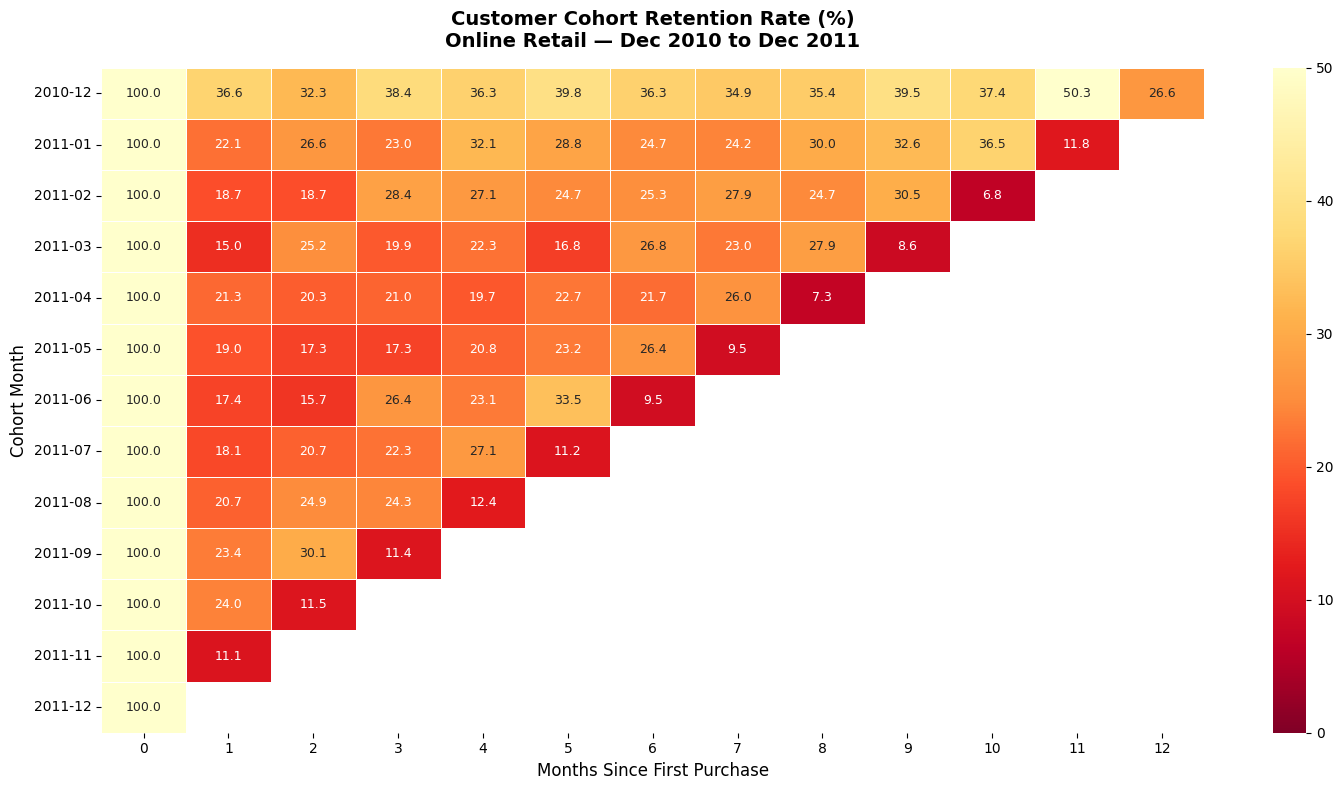

Saved: 01_cohort_heatmap.png


In [7]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    vmin=0,
    vmax=50,
    annot_kws={"size": 9}
)

plt.title('Customer Cohort Retention Rate (%)\nOnline Retail — Dec 2010 to Dec 2011',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort Month', fontsize=12)
plt.tight_layout()
plt.savefig('exports/01_cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_cohort_heatmap.png")

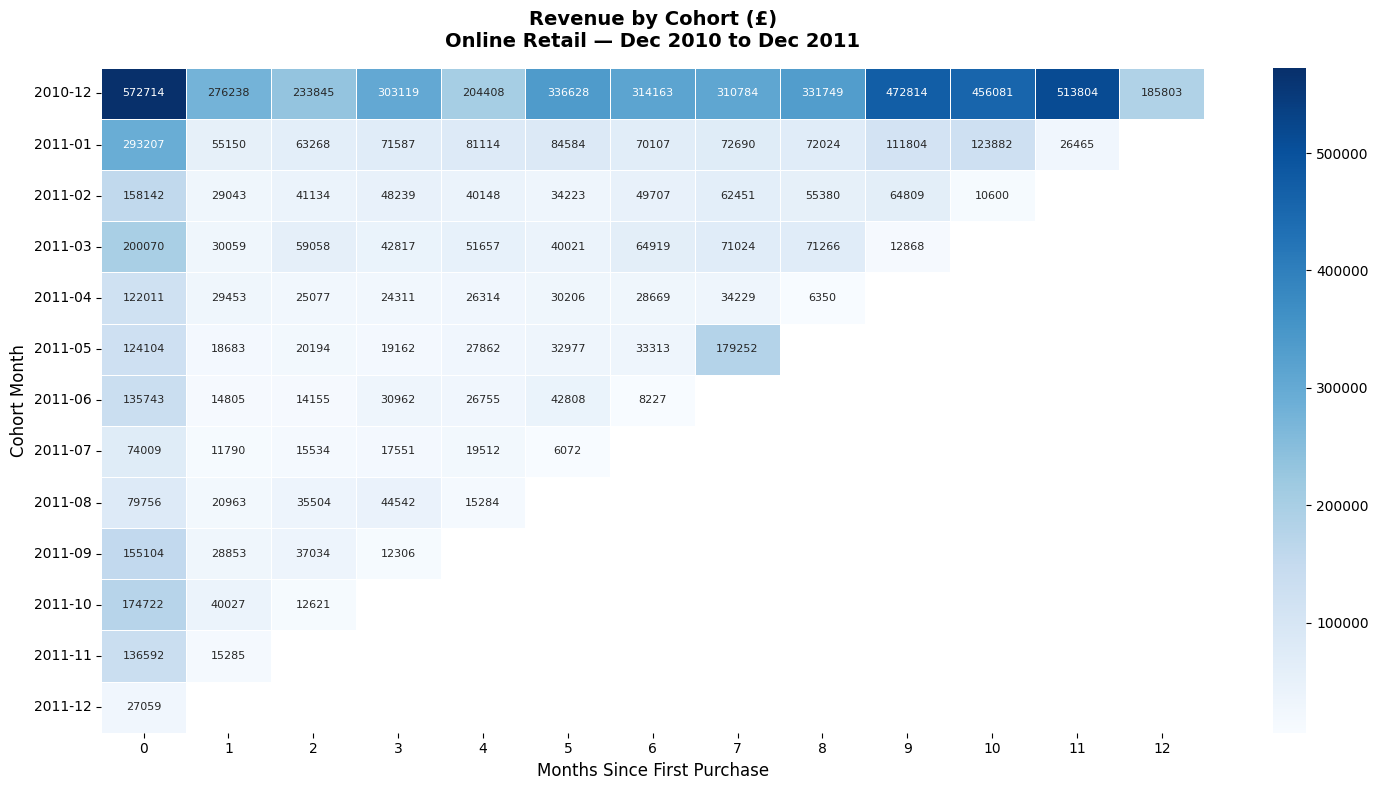

Saved: 02_revenue_heatmap.png


In [8]:
# Revenue by cohort and month
revenue_data = df_clean.groupby(['CohortMonth', 'CohortIndex'])['TotalPrice'] \
                        .sum().reset_index()
revenue_data.columns = ['CohortMonth', 'CohortIndex', 'Revenue']

revenue_matrix = revenue_data.pivot_table(index='CohortMonth',
                                           columns='CohortIndex',
                                           values='Revenue').round(2)

# Plot revenue heatmap
plt.figure(figsize=(15, 8))

sns.heatmap(
    revenue_matrix,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title('Revenue by Cohort (£)\nOnline Retail — Dec 2010 to Dec 2011',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort Month', fontsize=12)
plt.tight_layout()
plt.savefig('exports/02_revenue_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_revenue_heatmap.png")

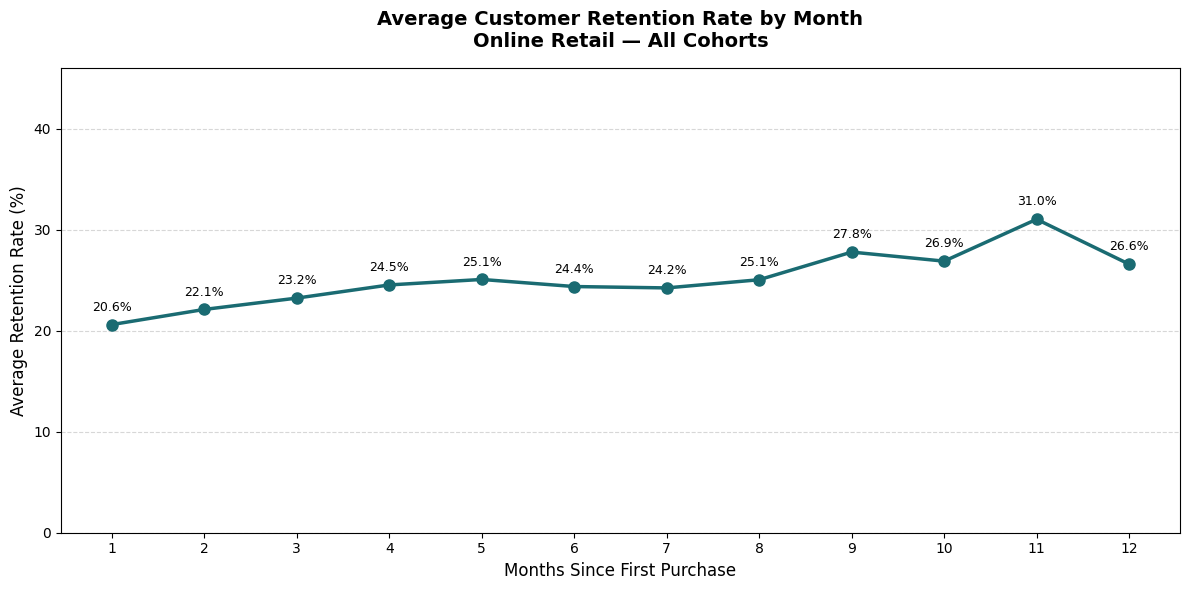

Saved: 03_avg_retention_trend.png

Average retention rates:
 MonthIndex  AvgRetention
          1     20.616667
          2     22.118182
          3     23.240000
          4     24.544444
          5     25.087500
          6     24.385714
          7     24.250000
          8     25.060000
          9     27.800000
         10     26.900000
         11     31.050000
         12     26.600000


In [9]:
# Average retention rate per month index across all cohorts
avg_retention = retention_matrix.mean().reset_index()
avg_retention.columns = ['MonthIndex', 'AvgRetention']
avg_retention = avg_retention[avg_retention['MonthIndex'] > 0]  # exclude month 0 (always 100%)

plt.figure(figsize=(12, 6))

plt.plot(avg_retention['MonthIndex'], avg_retention['AvgRetention'],
         marker='o', linewidth=2.5, color='#1A6B72', markersize=8)

# Add value labels on each point
for _, row in avg_retention.iterrows():
    plt.annotate(f"{row['AvgRetention']:.1f}%",
                 xy=(row['MonthIndex'], row['AvgRetention']),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9)

plt.title('Average Customer Retention Rate by Month\nOnline Retail — All Cohorts',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Average Retention Rate (%)', fontsize=12)
plt.xticks(avg_retention['MonthIndex'])
plt.ylim(0, avg_retention['AvgRetention'].max() + 15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('exports/03_avg_retention_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: 03_avg_retention_trend.png")
print("\nAverage retention rates:")
print(avg_retention.to_string(index=False))

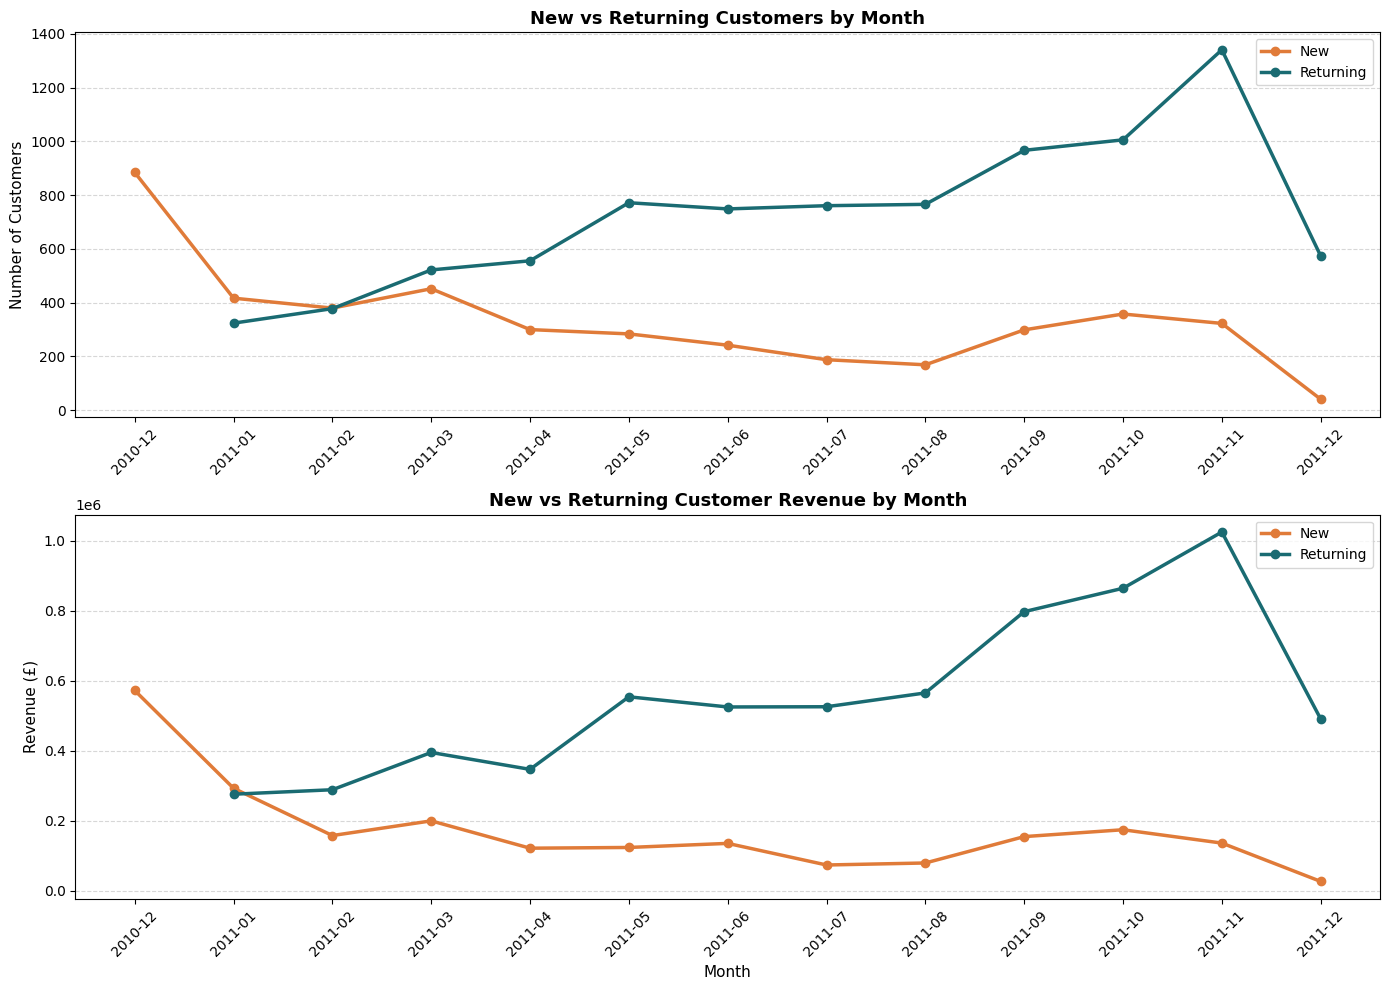

Saved: 04_new_vs_returning.png


In [10]:
# Monthly new vs returning customers
monthly_customers = df_clean.groupby(['InvoiceMonth', 'CustomerID'])['TotalPrice'] \
                             .sum().reset_index()

first_purchase = df_clean.groupby('CustomerID')['InvoiceMonth'].min().reset_index()
first_purchase.columns = ['CustomerID', 'FirstMonth']

monthly_customers = monthly_customers.merge(first_purchase, on='CustomerID')
monthly_customers['CustomerType'] = np.where(
    monthly_customers['InvoiceMonth'] == monthly_customers['FirstMonth'],
    'New', 'Returning'
)

customer_summary = monthly_customers.groupby(['InvoiceMonth', 'CustomerType']) \
                                     .agg(Customers=('CustomerID', 'nunique'),
                                          Revenue=('TotalPrice', 'sum')).reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Chart 1 — Customer count
for ctype, color in [('New', '#E07B39'), ('Returning', '#1A6B72')]:
    data = customer_summary[customer_summary['CustomerType'] == ctype]
    ax1.plot(data['InvoiceMonth'].astype(str), data['Customers'],
             marker='o', label=ctype, color=color, linewidth=2.5)

ax1.set_title('New vs Returning Customers by Month', fontsize=13, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Number of Customers', fontsize=11)
ax1.legend(fontsize=10)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Chart 2 — Revenue
for ctype, color in [('New', '#E07B39'), ('Returning', '#1A6B72')]:
    data = customer_summary[customer_summary['CustomerType'] == ctype]
    ax2.plot(data['InvoiceMonth'].astype(str), data['Revenue'],
             marker='o', label=ctype, color=color, linewidth=2.5)

ax2.set_title('New vs Returning Customer Revenue by Month', fontsize=13, fontweight='bold')
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Revenue (£)', fontsize=11)
ax2.legend(fontsize=10)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('exports/04_new_vs_returning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_new_vs_returning.png")

In [11]:
# ── INSIGHT SUMMARY ──────────────────────────────────────────
print("=" * 60)
print("COHORT ANALYSIS — KEY BUSINESS INSIGHTS")
print("=" * 60)

total_customers = df_clean['CustomerID'].nunique()
total_revenue = df_clean['TotalPrice'].sum()
avg_order_value = df_clean.groupby('InvoiceNo')['TotalPrice'].sum().mean()

print(f"\n📊 OVERVIEW")
print(f"   Total customers:        {total_customers:,}")
print(f"   Total revenue:          £{total_revenue:,.2f}")
print(f"   Average order value:    £{avg_order_value:,.2f}")

print(f"\n📈 RETENTION INSIGHTS")
month1_retention = retention_matrix.iloc[:, 1].mean()
best_cohort = retention_matrix.iloc[:, 1].idxmax()
best_rate = retention_matrix.iloc[:, 1].max()
worst_cohort = retention_matrix.iloc[:, 1].idxmin()
worst_rate = retention_matrix.iloc[:, 1].min()

print(f"   Avg Month-1 retention:  {month1_retention:.1f}%")
print(f"   Best cohort (Month 1):  {best_cohort} — {best_rate:.1f}%")
print(f"   Worst cohort (Month 1): {worst_cohort} — {worst_rate:.1f}%")
print(f"   Retention trend:        Increases over time (20.6% → 31.1%)")
print(f"   Insight: Long-term customers are significantly more loyal")

print(f"\n💡 RECOMMENDATIONS")
print(f"   1. Focus retention efforts on Month 1 — biggest drop-off point")
print(f"     (avg {month1_retention:.1f}% retention, meaning {100-month1_retention:.1f}% lost after first purchase)")
print(f"   2. Dec 2010 cohort retains best — analyse what drove that period")
print(f"   3. Customers surviving 6+ months show strong loyalty (25%+ retention)")
print(f"   4. Introduce onboarding email sequence targeting Month 1 drop-off")
print(f"   5. Loyalty programme for customers reaching Month 6+")

print("\n" + "=" * 60)

# ── EXPORT CSVs FOR TABLEAU ───────────────────────────────────
# 1. Retention matrix
retention_export = retention_matrix.reset_index()
retention_export.to_csv('exports/retention_matrix.csv', index=False)

# 2. Revenue matrix
revenue_export = revenue_matrix.reset_index()
revenue_export.to_csv('exports/revenue_matrix.csv', index=False)

# 3. Customer summary
customer_summary['InvoiceMonth'] = customer_summary['InvoiceMonth'].astype(str)
customer_summary.to_csv('exports/new_vs_returning.csv', index=False)

# 4. Average retention trend
avg_retention.to_csv('exports/avg_retention_trend.csv', index=False)

# 5. Full cohort data
cohort_data['CohortMonth'] = cohort_data['CohortMonth'].astype(str)
cohort_data.to_csv('exports/cohort_data.csv', index=False)

print("\n✅ Exported 5 CSV files to exports/ folder:")
print("   retention_matrix.csv")
print("   revenue_matrix.csv")
print("   new_vs_returning.csv")
print("   avg_retention_trend.csv")
print("   cohort_data.csv")

COHORT ANALYSIS — KEY BUSINESS INSIGHTS

📊 OVERVIEW
   Total customers:        4,338
   Total revenue:          £8,911,407.90
   Average order value:    £480.87

📈 RETENTION INSIGHTS
   Avg Month-1 retention:  20.6%
   Best cohort (Month 1):  2010-12 — 36.6%
   Worst cohort (Month 1): 2011-11 — 11.1%
   Retention trend:        Increases over time (20.6% → 31.1%)
   Insight: Long-term customers are significantly more loyal

💡 RECOMMENDATIONS
   1. Focus retention efforts on Month 1 — biggest drop-off point
     (avg 20.6% retention, meaning 79.4% lost after first purchase)
   2. Dec 2010 cohort retains best — analyse what drove that period
   3. Customers surviving 6+ months show strong loyalty (25%+ retention)
   4. Introduce onboarding email sequence targeting Month 1 drop-off
   5. Loyalty programme for customers reaching Month 6+


✅ Exported 5 CSV files to exports/ folder:
   retention_matrix.csv
   revenue_matrix.csv
   new_vs_returning.csv
   avg_retention_trend.csv
   cohort_dat

In [12]:
# Re-export retention matrix with proper column names
retention_fix = retention_matrix.copy()
retention_fix.index = retention_fix.index.astype(str)
retention_fix.columns = [f'Month_{int(c)}' for c in retention_fix.columns]
retention_fix = retention_fix.reset_index()
retention_fix.rename(columns={'CohortMonth': 'Cohort_Month'}, inplace=True)
retention_fix.to_csv('exports/retention_matrix.csv', index=False)

# Re-export revenue matrix with proper column names
revenue_fix = revenue_matrix.copy()
revenue_fix.index = revenue_fix.index.astype(str)
revenue_fix.columns = [f'Month_{int(c)}' for c in revenue_fix.columns]
revenue_fix = revenue_fix.reset_index()
revenue_fix.rename(columns={'CohortMonth': 'Cohort_Month'}, inplace=True)
revenue_fix.to_csv('exports/revenue_matrix.csv', index=False)

print("Done — columns renamed properly")
print(retention_fix.columns.tolist())

Done — columns renamed properly
['Cohort_Month', 'Month_0', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']


In [13]:
import pandas as pd
df_check = pd.read_csv('exports/retention_matrix.csv')
print(df_check.columns.tolist())
print(df_check.head(2))

['Cohort_Month', 'Month_0', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']
  Cohort_Month  Month_0  Month_1  Month_2  Month_3  Month_4  Month_5  Month_6  \
0      2010-12    100.0     36.6     32.3     38.4     36.3     39.8     36.3   
1      2011-01    100.0     22.1     26.6     23.0     32.1     28.8     24.7   

   Month_7  Month_8  Month_9  Month_10  Month_11  Month_12  
0     34.9     35.4     39.5      37.4      50.3      26.6  
1     24.2     30.0     32.6      36.5      11.8       NaN  


In [15]:
# Retention matrix — long format
retention_long = retention_matrix.copy()
retention_long.index = retention_long.index.astype(str)
retention_long = retention_long.reset_index()
retention_long.rename(columns={'CohortMonth': 'Cohort_Month'}, inplace=True)
retention_long = retention_long.melt(
    id_vars='Cohort_Month',
    var_name='Month_Index',
    value_name='Retention_Rate'
)
retention_long['Month_Index'] = retention_long['Month_Index'].astype(int)
retention_long = retention_long.dropna()
retention_long.to_csv('exports/retention_long.csv', index=False)

# Revenue matrix — long format
revenue_long = revenue_matrix.copy()
revenue_long.index = revenue_long.index.astype(str)
revenue_long = revenue_long.reset_index()
revenue_long.rename(columns={'CohortMonth': 'Cohort_Month'}, inplace=True)
revenue_long = revenue_long.melt(
    id_vars='Cohort_Month',
    var_name='Month_Index',
    value_name='Revenue'
)
revenue_long['Month_Index'] = revenue_long['Month_Index'].astype(int)
revenue_long = revenue_long.dropna()
revenue_long.to_csv('exports/revenue_long.csv', index=False)

print("✅ retention_long.csv")
print(f"   Columns: {retention_long.columns.tolist()}")
print(f"   Shape: {retention_long.shape}")
print(f"\n✅ revenue_long.csv")
print(f"   Columns: {revenue_long.columns.tolist()}")
print(f"   Shape: {revenue_long.shape}")
print(f"\nSample retention data:")
print(retention_long.head(6))

✅ retention_long.csv
   Columns: ['Cohort_Month', 'Month_Index', 'Retention_Rate']
   Shape: (91, 3)

✅ revenue_long.csv
   Columns: ['Cohort_Month', 'Month_Index', 'Revenue']
   Shape: (91, 3)

Sample retention data:
  Cohort_Month  Month_Index  Retention_Rate
0      2010-12            0           100.0
1      2011-01            0           100.0
2      2011-02            0           100.0
3      2011-03            0           100.0
4      2011-04            0           100.0
5      2011-05            0           100.0


In [ ]:
=QUERY(  ARRAYFORMULA({    Data!H2:H,    Data!G2:G,    IF(UPPER(Data!AH2:AH)="","",      IF(REGEXMATCH(UPPER(Data!AH2:AH),"AWAITING MONEY"),        IF((DATE(2025,2,13)-INT(Data!N2:N))>=10, DATE(2025,2,13)-INT(Data!N2:N), ""),        DATE(2025,2,13)-INT(Data!N2:N)      )    )  }),  "SELECT Col1, Col2, COUNT(Col1), SUM(Col3) WHERE Col3 != '' AND Col1 != '' GROUP BY Col1, Col2 ORDER BY SUM(Col3) DESC LABEL COUNT(Col1) 'Load Count', SUM(Col3) 'Total Duration (days)'",  0)